In [6]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [7]:
load_dotenv()

True

In [8]:
# llm = ChatOpenAI(model="gpt-4.1-mini")

In [9]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [10]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [12]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



In [13]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

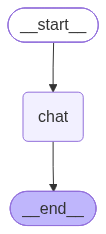

In [14]:
app

In [15]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [16]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='1728fd8d-4807-4f50-9c2f-34574e97a1d4')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='0bdee2082f46b29de1132fe886ea02ce')]}

In [17]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [18]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

In [20]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [21]:
print(final_result["messages"][-1].content)

Imagine you're **blindfolded** and standing somewhere on a mountain. Your goal is to get to the very **bottom of the valley** (the lowest point).

Here's how you'd do it using Gradient Descent:

1.  **Start Somewhere:** You're dropped off randomly on the mountain.

2.  **Feel the Slope (The "Gradient"):** You can't see, but you can feel the ground right under your feet. Which way is downhill? Is it steeper to your left? Straight ahead? Slightly behind you? This "feeling the slope" is what the "gradient" refers to – it tells you the direction of the steepest descent.

3.  **Take a Step Downhill (The "Descent"):** Once you've figured out the steepest downhill direction, you take a step in that direction.

4.  **Repeat:** You keep repeating steps 2 and 3:
    *   Feel the new slope.
    *   Take another step downhill.

5.  **Adjust Your Step Size (The "Learning Rate"):**
    *   **Too big a step:** If your steps are too large, you might jump right over the bottom of the valley and end up 